# WinCLIP MVTec Experiment

MVTec 데이터셋에서 `models.winclip.WinCLIP`을 PatchCore와 같은 `fit / predict / predict_batch` 인터페이스로 실행합니다.

In [1]:
import os
import sys

# Notebook을 MVTec 폴더 안에서 열어도 repo root 기준으로 실행되게 맞춥니다.
if os.path.basename(os.getcwd()) == "MVTec":
    os.chdir("..")

print(os.getcwd())

sys.path.append("..")

c:\Users\82105\lab


In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "MVTec":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import torch
import numpy as np

import config_mv
from datasets.mvtec import MyData
from models.winclip import WinCLIP
from utils.metrics import get_image_auc
from utils.visualization import show_result

In [3]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(device)

cpu


In [4]:
train_data = MyData(
    config_mv.CLASS_NAME,
    phase="train",
    batch_size=config_mv.BATCH_SIZE,
    shuffle=False,
    limit=config_mv.TRAIN_LIMIT,
)

test_data = MyData(
    config_mv.CLASS_NAME,
    phase="test",
    batch_size=config_mv.BATCH_SIZE,
    shuffle=False,
    limit=config_mv.TEST_LIMIT,
    limit_per_class=config_mv.TEST_LIMIT_PER_CLASS,
)

print("class:", config_mv.CLASS_NAME)
print("train:", len(train_data), "test:", len(test_data))

class: cable
train: 30 test: 27


In [5]:
winclip = WinCLIP(
    category=config_mv.CLASS_NAME,
    device=device,
    backbone="ViT-B-16-plus-240",
    pretrained_dataset="laion400m_e32",
    out_size_h=256,
    out_size_w=256,
    img_resize=256,
    img_cropsize=240,
    use_visual_gallery=True,
)

winclip.fit(train_data)

self.grid_size (15, 15)
fusion version: textual_visual


In [6]:
scores = []
heatmaps = []
imgs = []

for img, label in test_data:
    score, heatmap = winclip.predict(img)
    scores.append(score.item())
    heatmaps.append(heatmap)
    imgs.append(img)

print("scores:", np.round(scores, 4).tolist())

scores: [0.113, 0.1425, 0.144, 0.1293, 0.1325, 0.1457, 0.1325, 0.1237, 0.139, 0.1222, 0.1356, 0.1253, 0.1292, 0.1487, 0.1221, 0.1288, 0.1525, 0.1483, 0.1404, 0.1313, 0.1396, 0.1239, 0.1144, 0.1416, 0.1357, 0.1377, 0.1335]


In [7]:
image_auc = get_image_auc(test_data, winclip)
print("image AUROC:", image_auc)

image AUROC: 0.25000000000000006


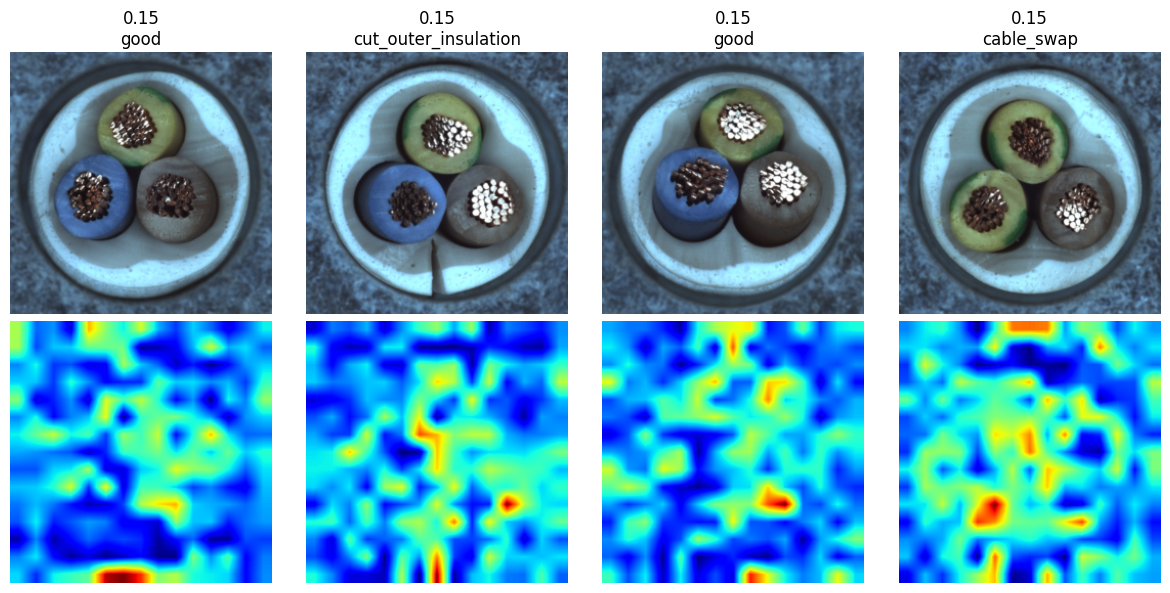

In [8]:
show_result(test_data, scores, heatmaps, k=4)